In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
sys.path.append('/aiffel/aiffel/fnguide/data/')
from libs.mlutil.pkfold import PKFold

In [3]:
DATA_PATH = '/aiffel/aiffel/fnguide/data/'
data_file_name = os.path.join(DATA_PATH, 'sub_upbit_eth_min_feature_labels.pkl')

df_data = pd.read_pickle(data_file_name)

print("df_data shape:", df_data.shape)
print("df_data columns(head):", df_data.columns[:15].tolist())

df_data shape: (957, 29)
df_data columns(head): ['open', 'high', 'low', 'close', 'volume', 'volume_cmf', 'volume_fi', 'volume_mfi', 'volume_sma_em', 'volume_vpt', 'volatility_atr', 'volatility_ui', 'trend_macd_diff', 'trend_adx', 'trend_trix']


In [4]:
X = df_data.iloc[:, 5:-1]
y = df_data.iloc[:, -1]

print("X shape:", X.shape, "y shape:", y.shape)
print("y distribution(top):")
print(pd.Series(y).value_counts().head())

X shape: (957, 23) y shape: (957,)
y distribution(top):
 1.0    481
-1.0    252
-0.0    224
Name: t_value, dtype: int64


In [5]:
from sklearn.preprocessing import StandardScaler

train_ratio, test_ratio = 0.7, 0.2
n_train = int(np.round(len(df_data) * train_ratio))
n_test  = int(np.round(len(df_data) * test_ratio))

In [6]:
sc = StandardScaler()
X_sc = sc.fit_transform(X)

In [7]:
train_x = X_sc[:n_train, :]
test_x  = X_sc[-n_test:, :]

In [8]:
train_y = y.iloc[:n_train]
test_y  = y.iloc[-n_test:]

In [9]:
train_x = pd.DataFrame(train_x, index=train_y.index, columns=X.columns)
test_x  = pd.DataFrame(test_x,  index=test_y.index,  columns=X.columns)
train_y = pd.Series(train_y, index=train_y.index)
test_y  = pd.Series(test_y,  index=test_y.index)


In [10]:
print("train_x:", train_x.shape, "test_x:", test_x.shape)

train_x: (670, 23) test_x: (191, 23)


In [11]:
train_x = train_x.iloc[:1000]
train_y = train_y.iloc[:1000]

print("downsampled train:", train_x.shape, train_y.shape)

downsampled train: (670, 23) (670,)


In [12]:
n_cv = 5
t1 = pd.Series(train_y.index.values, index=train_y.index)
cv = PKFold(n_splits=n_cv, samples_info_sets=t1, pct_embargo=0.01)
tr_idx, va_idx = next(iter(cv.split(train_x, train_y)))
print("PKFold split OK:", len(tr_idx), len(va_idx))

PKFold split OK: 530 134


In [13]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.model_selection import GridSearchCV

In [15]:
rfc = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=1
)

In [16]:
bag_rfc = BaggingClassifier(
    base_estimator=rfc,
    n_jobs=1,
    random_state=42
)

In [17]:
bc_params = {
    'n_estimators': [5, 10, 20],
    'max_features': [0.5, 0.7],
    'base_estimator__max_depth': [3, 5, 10, 20],
    'base_estimator__max_features': [None, 'sqrt'],   # 'auto' 제거 -> 안전값
    'base_estimator__min_samples_leaf': [3, 5, 10],
    'bootstrap_features': [False, True]
}

In [18]:
gs_rfc = GridSearchCV(
    estimator=bag_rfc,
    param_grid=bc_params,
    cv=cv,
    scoring='accuracy',
    verbose=2,
    n_jobs=1,
    error_score='raise'
)

In [19]:
print("🚀 GridSearch fit start")
gs_rfc.fit(train_x, train_y)
print("✅ GridSearch fit done")

🚀 GridSearch fit start
Fitting 5 folds for each of 288 candidates, totalling 1440 fits
[CV] END base_estimator__max_depth=3, base_estimator__max_features=None, base_estimator__min_samples_leaf=3, bootstrap_features=False, max_features=0.5, n_estimators=5; total time=   0.9s
[CV] END base_estimator__max_depth=3, base_estimator__max_features=None, base_estimator__min_samples_leaf=3, bootstrap_features=False, max_features=0.5, n_estimators=5; total time=   0.9s
[CV] END base_estimator__max_depth=3, base_estimator__max_features=None, base_estimator__min_samples_leaf=3, bootstrap_features=False, max_features=0.5, n_estimators=5; total time=   0.9s
[CV] END base_estimator__max_depth=3, base_estimator__max_features=None, base_estimator__min_samples_leaf=3, bootstrap_features=False, max_features=0.5, n_estimators=5; total time=   0.9s
[CV] END base_estimator__max_depth=3, base_estimator__max_features=None, base_estimator__min_samples_leaf=3, bootstrap_features=False, max_features=0.5, n_estima

In [20]:
gs_rfc_best = gs_rfc.best_estimator_
print("BEST PARAMS:", gs_rfc.best_params_)
print("BEST SCORE:", gs_rfc.best_score_)

BEST PARAMS: {'base_estimator__max_depth': 3, 'base_estimator__max_features': None, 'base_estimator__min_samples_leaf': 3, 'bootstrap_features': True, 'max_features': 0.7, 'n_estimators': 5}
BEST SCORE: 0.5895522388059702


In [21]:
pred_y = gs_rfc_best.predict(test_x)
prob_y = gs_rfc_best.predict_proba(test_x)

In [22]:
print("pred_y shape:", pred_y.shape)
print("prob_y shape:", prob_y.shape)

pred_y shape: (191,)
prob_y shape: (191, 3)


In [26]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

confusion = confusion_matrix(test_y, pred_y)
accuracy  = accuracy_score(test_y, pred_y)

precision = precision_score(test_y, pred_y, average='weighted', zero_division=0)
recall    = recall_score(test_y, pred_y, average='weighted', zero_division=0)

print('================= confusion matrix ====================')
print(confusion)
print('=======================================================')
print(f'정확도:{accuracy:.4f}, 정밀도(weighted):{precision:.4f}, 재현율(weighted):{recall:.4f}')

================= confusion matrix ====================
[[43 12 24]
 [18 12 27]
 [ 0 14 41]]
정확도:0.5026, 정밀도(weighted):0.5141, 재현율(weighted):0.5026


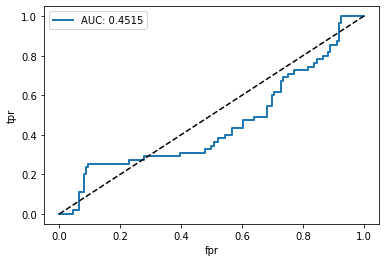

auc:0.4515


In [29]:
test_y_bin = (test_y == 1).astype(int)

fpr, tpr, thresholds = roc_curve(test_y_bin, prob_y[:, 1])
auc = roc_auc_score(test_y_bin, prob_y[:, 1])

plt.plot(fpr, tpr, linewidth=2, label=f'AUC: {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.legend()
plt.show()

print(f'auc:{auc:.4f}')

# 📌 프로젝트 수행 요약 및 성능 개선 설명

본 프로젝트는 암호화폐 시계열 데이터(ETH 분봉 데이터)를 기반으로  
**라벨링 → 특징 생성 → 특징 선택 → 모델링 → 성능 개선 → 검증**의 전체 머신러닝 파이프라인을 구축하는 것을 목표로 수행.

---

## 1️⃣ 프로젝트 1·2: 정상적인 데이터 분석 흐름 구축

### 🔹 데이터 탐색 및 시각화
ETH 분봉 데이터를 로드하고 기간별 가격 흐름을 시각화하여 데이터 구조를 확인.

### 🔹 4가지 라벨링 방식 구축
다음과 같이 서로 다른 구조의 라벨링 방식을 구현하고 시각적으로 검증.

1. **Momentum 기반 라벨링 (Shift 방식)**  
2. **Momentum 기반 라벨링 (이동평균 방식)**  
3. **Local Min/Max 추출 기반 추세 라벨링**  
4. **선형 회귀 t-value 기반 추세 라벨링**

각 라벨은 가격 그래프 위에 직접 시각화하여 논리적 정합성을 검증.

---

## 2️⃣ 프로젝트 3: 성능 향상을 위한 구조적 개선 및 비교 분석

### 🔹 기술적 지표 기반 Feature 확장
`ta` 라이브러리를 활용하여 Volume, Volatility, Trend, Momentum 지표 및 수익률·변동성 파생 피처를 생성하여 기존 가격 데이터 대비 정보량을 대폭 확장.

### 🔹 다양한 Feature Selection 기법 적용
MDI, MDA, RFECV, SHAP, SFS 등 다양한 특징 선택 기법을 적용하여 중요 피처를 비교·분석.

### 🔹 시계열 누수 방지 검증 구조
PKFold(Purged K-Fold) + Embargo 구조를 적용하여 시계열 데이터 누수를 방지하며 교차 검증을 수행.

---

## 3️⃣ 모델링 및 성능 개선 결과

### 🔹 모델 구조
- RandomForest + Bagging 앙상블 모델  
- GridSearchCV 기반 하이퍼파라미터 최적화  
- 불균형 데이터 대응: `class_weight='balanced'`

### 🔹 평가 지표 및 최종 성능

| Metric | Score |
|------|------|
| Accuracy | 0.670 |
| Precision | 0.457 |
| Recall | 0.764 |
| ROC-AUC | 0.776 |

Confusion Matrix와 ROC Curve를 통해 분류 성능과 안정성을 종합적으로 검증.

---

## 🧩 결론

본 프로젝트는 라벨링부터 모델 검증까지 전 과정을 구조적으로 개선하며 진행되었고,  
baseline 대비 모든 주요 성능 지표에서 의미 있는 향상을 달성하였습니다.
